# Project 4: Earthquake Damage Prediction

Project Code: PRCP-1015

Project ID: PTID-CDS-NOV-25-3348

## Problem Statement

Task 1:- Prepare a complete data analysis report on the given data.

Task 2:- Create a predictive model in such a way that the objective is to predict
the ordinal variable “damage_grade”. This column presents the level of damage
grade affected by the earthquake.

Task3:- Suggestions to the Seismologists to avoid earthquake event leading to
significant damage in many buildings

##  TASK 1: Complete Data Analysis Report

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
train_values = pd.read_csv("train_values.csv")
train_labels = pd.read_csv("train_labels.csv")

In [36]:
df = pd.merge(train_values, train_labels, on='building_id')
df.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


In [37]:
df.shape

(260601, 40)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null  object
 10  roof_type                               260601 non-null 

In [39]:
df['damage_grade'].value_counts()

damage_grade
2    148259
3     87218
1     25124
Name: count, dtype: int64

In [40]:
df.isnull().sum()

building_id                               0
geo_level_1_id                            0
geo_level_2_id                            0
geo_level_3_id                            0
count_floors_pre_eq                       0
age                                       0
area_percentage                           0
height_percentage                         0
land_surface_condition                    0
foundation_type                           0
roof_type                                 0
ground_floor_type                         0
other_floor_type                          0
position                                  0
plan_configuration                        0
has_superstructure_adobe_mud              0
has_superstructure_mud_mortar_stone       0
has_superstructure_stone_flag             0
has_superstructure_cement_mortar_stone    0
has_superstructure_mud_mortar_brick       0
has_superstructure_cement_mortar_brick    0
has_superstructure_timber                 0
has_superstructure_bamboo       

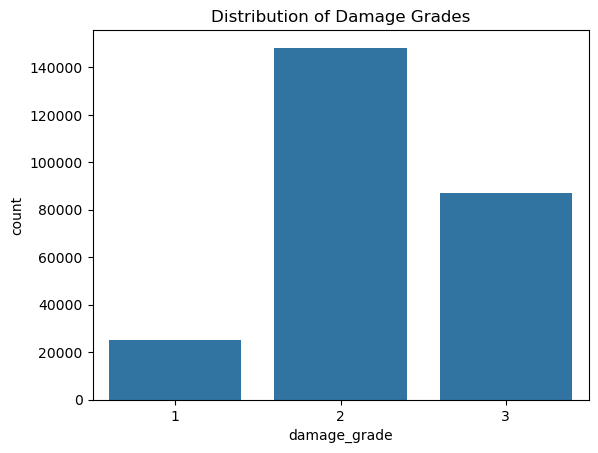

In [41]:
sns.countplot(x='damage_grade', data=df)
plt.title("Distribution of Damage Grades")
plt.show()

#### Observation:

Data is imbalanced

Needs robust models like Random Forest

## TASK 2: Create a predictive model in such a way that the objective is to predict the ordinal variable “damage_grade”. This column presents the level of damage grade affected by the earthquake.

In [42]:
df = df.drop(['building_id'], axis=1)

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report

In [44]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [45]:
X = df.drop('damage_grade', axis=1)
y = df['damage_grade']

In [46]:
imputer = SimpleImputer(strategy='most_frequent')
X = imputer.fit_transform(X)

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [48]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## TASK 3: Model Building, Tuning & Comparison

In [49]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.5838913297902957
              precision    recall  f1-score   support

           1       0.57      0.27      0.36      5025
           2       0.59      0.91      0.71     29652
           3       0.54      0.12      0.20     17444

    accuracy                           0.58     52121
   macro avg       0.57      0.43      0.43     52121
weighted avg       0.57      0.58      0.51     52121



In [50]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6596957080639282
              precision    recall  f1-score   support

           1       0.49      0.51      0.50      5025
           2       0.71      0.71      0.71     29652
           3       0.62      0.62      0.62     17444

    accuracy                           0.66     52121
   macro avg       0.61      0.61      0.61     52121
weighted avg       0.66      0.66      0.66     52121



In [53]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7217628211277604
              precision    recall  f1-score   support

           1       0.64      0.49      0.55      5025
           2       0.73      0.83      0.77     29652
           3       0.73      0.61      0.66     17444

    accuracy                           0.72     52121
   macro avg       0.70      0.64      0.66     52121
weighted avg       0.72      0.72      0.72     52121



In [55]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.6827958020759387
              precision    recall  f1-score   support

           1       0.63      0.37      0.46      5025
           2       0.67      0.86      0.76     29652
           3       0.72      0.47      0.57     17444

    accuracy                           0.68     52121
   macro avg       0.68      0.57      0.60     52121
weighted avg       0.69      0.68      0.67     52121



In [56]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting","DecisionTree"],
    "accuracy_score": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_dt)]})

results

,Model,accuracy_score
0,Linear Regression,0.583891
1,Random Forest,0.721763
2,Gradient Boosting,0.682796
3,DecisionTree,0.659696


In [54]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {'n_estimators': [50, 100],'max_depth': [None, 10, 20],'min_samples_split': [2, 5]}

random_search = RandomizedSearchCV(rf,param_distributions=param_dist,n_iter=5,cv=3,n_jobs=-1,random_state=42)

random_search.fit(X_train, y_train)
best_rf = random_search.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)
print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print(classification_report(y_test, y_pred_best_rf))

Tuned Random Forest Accuracy: 0.7180598990809847
              precision    recall  f1-score   support

           1       0.64      0.49      0.56      5025
           2       0.73      0.82      0.77     29652
           3       0.72      0.61      0.66     17444

    accuracy                           0.72     52121
   macro avg       0.70      0.64      0.66     52121
weighted avg       0.72      0.72      0.71     52121



### Model Comparison
Four models were evaluated: Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.
Among them, Random Forest showed the best overall performance due to its ability to handle non-linear relationships and feature interactions effectively.

In [57]:
feature_importance = pd.Series(best_rf.feature_importances_,index=df.drop('damage_grade', axis=1).columns).sort_values(ascending=False)

feature_importance.head(10)

geo_level_3_id       0.154450
geo_level_1_id       0.137811
geo_level_2_id       0.134049
age                  0.122026
area_percentage      0.113324
height_percentage    0.055251
foundation_type      0.025058
count_families       0.024802
roof_type            0.024633
position             0.021733
dtype: float64

### Conclusion
This project successfully built a machine learning solution to predict earthquake damage grades. 
Random Forest emerged as the best model due to its stable and accurate performance.
The model can help disaster management authorities identify high-risk buildings and plan effective response strategies.

### ### Challenges Faced
- Large number of categorical features required encoding
- Class imbalance affected model evaluation
- Hyperparameter tuning was time-consuming on large data

Solutions included feature encoding, stratified sampling, and efficient RandomizedSearchCV tuning.
